In [1]:
import h5py
import numpy as np
import os 
import matplotlib.pyplot as plt

# predefined parameters
file_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250310_wtnoer_60min"
sN = ["ribosomeR1", "ribosomeR2", "ribosomeR3", "ribosomeR4", "ribosomeGrep", "ribosomeR80"]

In [2]:
def getIdx(name):
    return int(sN.index(name)+1)

def get_ribosome_coords_all_timeframes(*,file_dir_name, ribosome_species=None):
    """
    Extract coordinates of translating ribosomes at all time frames for a specific replicate.
    
    Parameters:
    -----------
    file_dir_name : str
        Name of the directory containing the hdf5 files with the fiile name 
    ribosome_species : str or list
        Species name(s) for translating ribosomes. If None, will use 'ribosome_bound'
        
    Returns:l
    --------
    dict: Dictionary with time points as keys and numpy arrays of coordinates as values
    """
    if ribosome_species is None:
        raise ValueError("ribosome_species is None")
    
    if isinstance(ribosome_species, str):
        ribosome_species = [ribosome_species]
    traj = h5py.File(file_dir_name)
    time_coords = {}
    # check if the species names are correct in the traj file
    sNbin = traj['Parameters']['SpeciesNames']
    sN = []

    for n in sNbin:

        sN.append(n[0])
        
    for species in ribosome_species:
        if species not in sN:
            raise ValueError(f"Species {species} not found in {file_dir_name}")
    
    
    
    # Get all available time points
    times = traj['Simulations']['0000001']['LatticeTimes'][:]
    print("times: ", times)
    # return 
    for t_idx, t in enumerate(times):
        t_int = int(t)
        t_str = f'{t_int:010d}'  # Format time string to match your existing pattern
        
        time_coords[t_int] = {}
        # Get lattice data for this time point
        pL = np.array(traj['Simulations']['0000001']['Lattice'][t_str])
        
        # we save the coordinates in a way that time_coords[t_int][spec] = coordinates of spec at time t_int
        for spec in ribosome_species:
            scoords = None
            spec_idx = getIdx(spec)
            scoords = np.argwhere(pL == spec_idx)
            

            if scoords is not None and len(scoords) > 0:
                scoords = scoords.T[0:3].T
                time_coords[t_int][spec] = scoords
            else:
                time_coords[t_int][spec] = None
        
    
    return time_coords





In [3]:
import logging
import multiprocessing
from functools import partial

def process_file(file_path, ribosome_species=None):
    """
    Process a single .lm file to extract ribosome coordinates.
    
    Parameters:
    -----------
    file_path : str
        Full path to the .lm file
    ribosome_species : list
        List of ribosome species names to extract
        
    Returns:
    --------
    dict: Dictionary with time points as keys and coordinates for each species
    """
    # Reuse your existing function to get coordinates
    return get_ribosome_coords_all_timeframes(
        file_dir_name=file_path, 
        ribosome_species=ribosome_species
    )

def process_files_parallel(file_paths, ribosome_species=None, max_workers=6):
    """
    Process multiple .lm files in parallel to extract ribosome coordinates.
    
    Parameters:
    -----------
    file_paths : list
        List of paths to .lm files
    ribosome_species : list
        List of ribosome species names to extract
    max_workers : int
        Maximum number of CPU cores to use
        
    Returns:
    --------
    dict: Dictionary with file paths as keys and coordinate data as values
    """
    # Determine the number of cores to use
    num_cores = min(multiprocessing.cpu_count(), max_workers)
    logging.info(f"Processing {len(file_paths)} files using {num_cores} CPU cores")
    
    # Create a pool of workers
    with multiprocessing.Pool(processes=num_cores) as pool:
        # Create a partial function with the ribosome species parameter
        
        process_func = partial(process_file, ribosome_species=ribosome_species)
        logging.info(f"Processing {file_paths} files.")
        # Map the function to each file path and collect results
        results = pool.map(process_func, file_paths)
    
    # Combine results into a dictionary with file paths as keys
    return dict(zip(file_paths, results))

In [4]:
# After getting all ribosome coordinates
import pandas as pd
from scipy.spatial.distance import euclidean
import matplotlib.pyplot as plt
import numpy as np

def save_coords_to_csv_and_calculate_distances(ribosome_coords_all_files, nucleus_center, output_dir=None):
    """
    Save ribosome coordinates to CSV files and calculate distances to nucleus center
    
    Parameters:
    -----------
    ribosome_coords_all_files : dict
        Dictionary with file paths as keys and coordinate data as values
    nucleus_center : list
        [x, y, z] coordinates of the nucleus center
    output_dir : str, optional
        Directory to save CSV files, if None uses same directory as input files
        
    Returns:
    --------
    dict: Dictionary with file paths as keys and average distances over time as values
    """
    # Store average distances for each file
    avg_distances_by_file = {}
    
    # Process each file
    for file_path, time_coords in ribosome_coords_all_files.items():
        # Extract the filename without path
        file_name = os.path.basename(file_path)
        base_name = os.path.splitext(file_name)[0]
        
        # Use same directory as input file if output_dir not specified
        if output_dir is None:
            output_dir = os.path.dirname(file_path)
        
        # Create a DataFrame to store all coordinates and distances
        all_data = []
        avg_distances_over_time = {}
        
        # Process each time point
        for time_point, species_coords in time_coords.items():
            all_coords_at_time = []
            all_distances_at_time = []
            
            # Process each ribosome species
            for species, coords in species_coords.items():
                if coords is not None:
                    # Calculate distance to nucleus for each coordinate
                    for coord in coords:
                        distance = euclidean(coord, nucleus_center)
                        all_data.append({
                            'time': time_point,
                            'species': species,
                            'x': coord[0],
                            'y': coord[1],
                            'z': coord[2],
                            'distance_to_nucleus': distance
                        })
                        all_distances_at_time.append(distance)
            
            # Calculate average distance at this time point
            if all_distances_at_time:
                avg_distances_over_time[time_point] = np.mean(all_distances_at_time)
        
        # Save all data to CSV
        if all_data:
            df = pd.DataFrame(all_data)
            csv_path = os.path.join(output_dir, f"{base_name}_ribosome_coords.csv")
            df.to_csv(csv_path, index=False)
            print(f"Saved coordinates to {csv_path}")
            
            # Store average distances for this file
            avg_distances_by_file[file_name] = avg_distances_over_time
    
    return avg_distances_by_file

def plot_average_distances(avg_distances_by_file):
    """
    Plot the average distances of translating ribosomes to nucleus center over time
    
    Parameters:
    -----------
    avg_distances_by_file : dict
        Dictionary with file paths as keys and average distances over time as values
    """
    plt.figure(figsize=(10, 6))
    
    for file_name, avg_distances in avg_distances_by_file.items():
        # Sort by time to ensure proper line ordering
        times = sorted(avg_distances.keys())
        distances = [avg_distances[t] for t in times]
        
        # Plot this file's data
        plt.plot(times, distances, label=f"{os.path.basename(file_name)}")
    
    # Calculate overall average across all files if there are multiple files
    if len(avg_distances_by_file) > 1:
        # Get all unique time points
        all_times = sorted(set(t for avg_dist in avg_distances_by_file.values() for t in avg_dist.keys()))
        
        # Calculate average at each time point
        overall_avg = []
        for t in all_times:
            values = [avg_dist.get(t) for avg_dist in avg_distances_by_file.values() if t in avg_dist]
            if values:
                overall_avg.append(np.mean(values))
            else:
                overall_avg.append(None)
        
        # Plot overall average
        plt.plot(all_times, overall_avg, 'k--', linewidth=2, label='Overall Average')
    
    plt.xlabel('Time')
    plt.ylabel('Average Distance to Nucleus Center')
    plt.title('Translating Ribosomes Distance to Nucleus Center Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    output_dir = os.path.dirname(list(avg_distances_by_file.keys())[0])
    plt.savefig(os.path.join(output_dir, 'average_distance_to_nucleus.png'), dpi=300)
    plt.show()

/home/tianyu/miniconda3/envs/ylm2.5/lib/python3.7/site-packages/ipykernel_launcher.py:24: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
/home/tianyu/miniconda3/envs/ylm2.5/lib/python3.7/site-packages/ipykernel_launcher.py:24: H5pyDeprecationWarning: The default file mode will change to 'r' (read-only) in h5py 3.0. To suppress this warning, pass the mode you need to h5py.File(), or set the global default h5.get_config().default_file_mode, or set the environment variable H5PY_DEFAULT_READONLY=1. Available modes are: 'r', 'r+', 'w', 'w-'/'x', 'a'. See the docs for details.
/home/tianyu/miniconda3/envs/ylm2.5/lib/python3.7/site-packages/ipykernel_launcher.py:24: H5pyDeprecationWarning: The 

times:  [0.000e+00 1.000e+00 2.000e+00 ... 3.598e+03 3.599e+03 3.600e+03]
times:  [0.000e+00 1.000e+00 2.000e+00 ... 3.598e+03 3.599e+03 3.600e+03]
times:  [0.000e+00 1.000e+00 2.000e+00 ... 3.598e+03 3.599e+03 3.600e+03]
times:  [0.000e+00 1.000e+00 2.000e+00 ... 3.598e+03 3.599e+03 3.600e+03]
times:  [0.000e+00 1.000e+00 2.000e+00 ... 3.598e+03 3.599e+03 3.600e+03]
Saved coordinates to /data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250310_wtnoer_60min/yeast1.14.3mt20250304_4_t60.0minGAE11.1mMnoERwt_gpu4_ribosome_coords.csv
Saved coordinates to /data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250310_wtnoer_60min/yeast1.14.3mt20250304_5_t60.0minGAE11.1mMnoERwt_gpu4_ribosome_coords.csv
Saved coordinates to /data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250310_wtnoer_60min/yeast1.14.3mt20250304_3_t60.0minGAE11.1mMnoERwt_gpu4_ribosome_coords.csv
Saved coordinates to /data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250310_wtnoer_60min/yeast1.14.3mt20250303_1

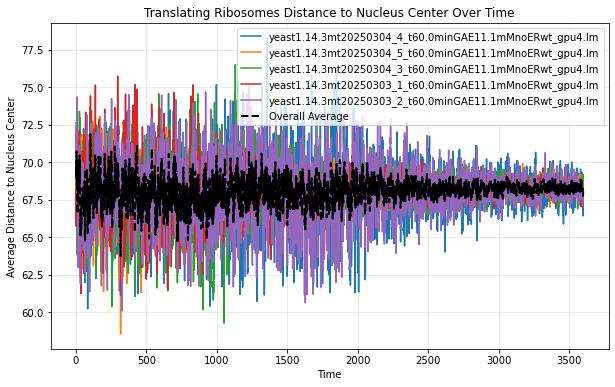

In [5]:
# Example usage:
files = [os.path.join(file_dir, f) for f in os.listdir(file_dir) if f.endswith('.lm')]

ribosome_coords_all_files = process_files_parallel(files, ribosome_species=sN, max_workers=6)

nucleus_center = [131, 76, 110]

# Save coordinates and calculate distances
avg_distances = save_coords_to_csv_and_calculate_distances(ribosome_coords_all_files, nucleus_center)

# Plot average distances
plot_average_distances(avg_distances)

In [ ]:
def plot_average_distances_from_csv(csv_files=None, output_dir=None):
    """
    Plot the average distances of translating ribosomes to nucleus center over time from CSV files
    
    Parameters:
    -----------
    csv_files : list, optional
        List of CSV file paths to process. If None, looks for *_ribosome_coords.csv files in output_dir
    output_dir : str, optional
        Directory containing CSV files (if csv_files=None) and where to save the plot
    """
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    import glob
    
    # If no specific CSV files provided, look for them in output_dir
    if csv_files is None:
        if output_dir is None:
            output_dir = '.'  # Default to current directory
        csv_files = glob.glob(os.path.join(output_dir, '*_ribosome_coords.csv'))
        if not csv_files:
            print("No CSV files found matching *_ribosome_coords.csv pattern")
            return
    
    # Set output_dir based on first file if not specified
    if output_dir is None:
        output_dir = os.path.dirname(csv_files[0])
    
    # Dictionary to store average distances for each file
    avg_distances_by_file = {}
    
    # Process each CSV file
    for csv_path in csv_files:
        file_name = os.path.basename(csv_path)
        print(f"Processing {file_name}...")
        
        # Read the CSV file
        try:
            df = pd.read_csv(csv_path)
            
            # Check if necessary columns exist
            if 'time' not in df.columns or 'distance_to_nucleus' not in df.columns:
                print(f"Warning: {file_name} is missing required columns. Skipping.")
                continue
                
            # Calculate average distance for each time point
            avg_distances = df.groupby('time')['distance_to_nucleus'].mean().to_dict()
            avg_distances_by_file[file_name] = avg_distances
            
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    
    # If no valid data was found, exit
    if not avg_distances_by_file:
        print("No valid data found in the CSV files")
        return
    
    # Create the plot
    plt.figure(figsize=(10, 6))
    
    for file_name, avg_distances in avg_distances_by_file.items():
        # Sort by time to ensure proper line ordering
        times = sorted(avg_distances.keys())
        distances = [avg_distances[t] for t in times]
        
        # Plot this file's data
        plt.plot(times, distances, label=f"{os.path.splitext(file_name)[0]}")
    
    # Calculate overall average across all files if there are multiple files
    if len(avg_distances_by_file) > 1:
        # Get all unique time points
        all_times = sorted(set(t for avg_dist in avg_distances_by_file.values() for t in avg_dist.keys()))
        
        # Calculate average at each time point
        overall_avg = []
        for t in all_times:
            values = [avg_dist.get(t) for avg_dist in avg_distances_by_file.values() if t in avg_dist]
            if values:
                overall_avg.append(np.mean(values))
            else:
                overall_avg.append(None)
        
        # Plot overall average
        plt.plot(all_times, overall_avg, 'k--', linewidth=2, label='Overall Average')
    
    plt.xlabel('Time')
    plt.ylabel('Average Distance to Nucleus Center')
    plt.title('Translating Ribosomes Distance to Nucleus Center Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Save the plot
    output_file = os.path.join(output_dir, 'average_distance_to_nucleus_from_csv.png')
    plt.savefig(output_file, dpi=300)
    print(f"Saved plot to {output_file}")
    plt.show()
    
    return avg_distances_by_file

comparison


In [29]:
def compare_distance_and_counts(set1_files, set2_files, set1_label="Set 1", set2_label="Set 2", 
                              output_dir=None, output_filename="ribosome_comparison.png"):
    """
    Compare and plot average distances and average ribosome counts for two sets of data
    
    Parameters:
    -----------
    set1_files : list
        List of CSV file paths for the first set of data
    set2_files : list
        List of CSV file paths for the second set of data
    set1_label : str, optional
        Label for the first set (default: "Set 1")
    set2_label : str, optional
        Label for the second set (default: "Set 2")
    output_dir : str, optional
        Directory where to save the plot. If None, uses directory of first file
    output_filename : str, optional
        Filename for the output plot (default: "ribosome_comparison.png")
        
    Returns:
    --------
    tuple: (set1_data, set2_data) - Tuples containing the distances and counts for each set
    """
    import os
    import pandas as pd
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Set output directory
    if output_dir is None and set1_files:
        output_dir = os.path.dirname(set1_files[0])
    elif output_dir is None:
        output_dir = '.'  # Default to current directory
    plt.style.use('default')
    plt.rcParams['figure.figsize'] = [10, 6]
    plt.rcParams['figure.dpi'] = 600
    plt.rcParams['font.size'] = 18  # Increase base font size
    plt.rcParams['axes.titlesize'] = 28  # Increase title font size
    plt.rcParams['axes.labelsize'] = 18  # Increase axis label font size
    plt.rcParams['xtick.labelsize'] = 18  # Increase tick label font size
    plt.rcParams['ytick.labelsize'] = 18  # Increase tick label font size
    plt.rcParams['legend.fontsize'] = 18  # Increase legend font size

    # Process each set of files
    def process_file_set(files):
        # Track data separately for each file
        file_data = {}
        
        for csv_path in files:
            file_name = os.path.basename(csv_path)
            try:
                df = pd.read_csv(csv_path)
                if 'time' not in df.columns or 'distance_to_nucleus' not in df.columns:
                    print(f"Warning: {file_name} is missing required columns. Skipping.")
                    continue
                
                # Initialize data structures for this file
                file_data[file_name] = {
                    'distances': {},
                    'counts': {}
                }
                
                # Process each time point for this file
                for time, group in df.groupby('time'):
                    # Store distances for this time point
                    file_data[file_name]['distances'][time] = group['distance_to_nucleus'].tolist()
                    
                    # Store count for this time point
                    file_data[file_name]['counts'][time] = len(group)
                
            except Exception as e:
                print(f"Error processing {file_name}: {e}")
        
        # Calculate average distances and counts across files
        avg_distances = {}
        avg_counts = {}
        
        # Get all unique time points across all files
        all_times = sorted(set([
            time 
            for file_info in file_data.values() 
            for time in file_info['distances'].keys()
        ]))
        
        # Calculate averages for each time point
        for time in all_times:
            # Collect distances from all files that have this time point
            all_distances = []
            for file_info in file_data.values():
                if time in file_info['distances']:
                    all_distances.extend(file_info['distances'][time])
            
            if all_distances:
                avg_distances[time] = np.mean(all_distances)
            
            # Calculate average count (average number of ribosomes per file at this time)
            counts_for_time = [
                file_info['counts'].get(time, 0)
                for file_info in file_data.values()
            ]
            
            if counts_for_time:
                avg_counts[time] = np.mean(counts_for_time)
        
        return avg_distances, avg_counts
    
    # Process both sets
    print(f"Processing {set1_label} files ({len(set1_files)} files)...")
    set1_distances, set1_counts = process_file_set(set1_files)
    
    print(f"Processing {set2_label} files ({len(set2_files)} files)...")
    set2_distances, set2_counts = process_file_set(set2_files)
    
    # Create the plots (2 rows, 1 column)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6*2))
    
    # 1. Plot average distances
    # Convert times to minutes and filter to plot one point per minute
    def filter_minute_intervals(times_dict):
        # Convert seconds to minutes
        minute_groups = {}
    
        for t, value in sorted(times_dict.items()):
            # Convert to minutes (assuming t is in seconds)
            minute = int(t / 60)
            
            # Add to the appropriate minute group
            if minute not in minute_groups:
                minute_groups[minute] = []
            minute_groups[minute].append(value)
        
        # Calculate average for each minute
        minute_dict = {}
        for minute, values in minute_groups.items():
            minute_dict[minute] = sum(values) / len(values)
            
        return minute_dict
    
    # Apply filtering
    set1_dist_minutes = filter_minute_intervals(set1_distances)
    set2_dist_minutes = filter_minute_intervals(set2_distances)
    set1_counts_minutes = filter_minute_intervals(set1_counts)
    set2_counts_minutes = filter_minute_intervals(set2_counts)
    
    # Plot distances
    spacing = 28.8 #nm/cube
    set1_minutes = sorted(set1_dist_minutes.keys())
    set1_dist_values = [set1_dist_minutes[t] * spacing * 1e-3 for t in set1_minutes]
    
    set2_minutes = sorted(set2_dist_minutes.keys())
    set2_dist_values = [set2_dist_minutes[t] * spacing * 1e-3 for t in set2_minutes]
    
    ax1.plot(set1_minutes, set1_dist_values,  label=set1_label)
    ax1.plot(set2_minutes, set2_dist_values,  label=set2_label)
    
    ax1.set_xlabel('Time (minutes)')
    ax1.set_ylabel('Distance to Nucleus (µm)')
    # ax1.set_title('Comparison of Average Ribosome Distance to Nucleus')
    ax1.legend()
    # ax1.grid(True, alpha=0.3)
    
    # 2. Plot average ribosome counts
    set1_count_minutes = sorted(set1_counts_minutes.keys())
    set1_count_values = [set1_counts_minutes[t] for t in set1_count_minutes]
    
    set2_count_minutes = sorted(set2_counts_minutes.keys())
    set2_count_values = [set2_counts_minutes[t] for t in set2_count_minutes]
    
    ax2.plot(set1_count_minutes, set1_count_values,  label=set1_label)
    ax2.plot(set2_count_minutes, set2_count_values,  label=set2_label)
    
    ax2.set_xlabel('Time (minutes)')
    ax2.set_ylabel('Counts')
    # ax2.set_title('Comparison of Translating Ribosome Counts')
    ax2.legend()
    # ax2.grid(True, alpha=0.3)
    
    # Add a title for the entire figure
    # plt.suptitle(f'Comparison: {set1_label} vs {set2_label}', fontsize=16)
    
    # Adjust layout and save
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Make room for the suptitle
    output_path = os.path.join(output_dir, output_filename)
    plt.savefig(output_path, dpi=300)
    print(f"Saved comparison plot to {output_path}")
    plt.show()
    
    return (set1_distances, set1_counts), (set2_distances, set2_counts)


Processing Normal files (5 files)...
Processing Effective files (5 files)...
Saved comparison plot to /data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250326_wtnoer_riboeff_1787/ribosome_comparison.png


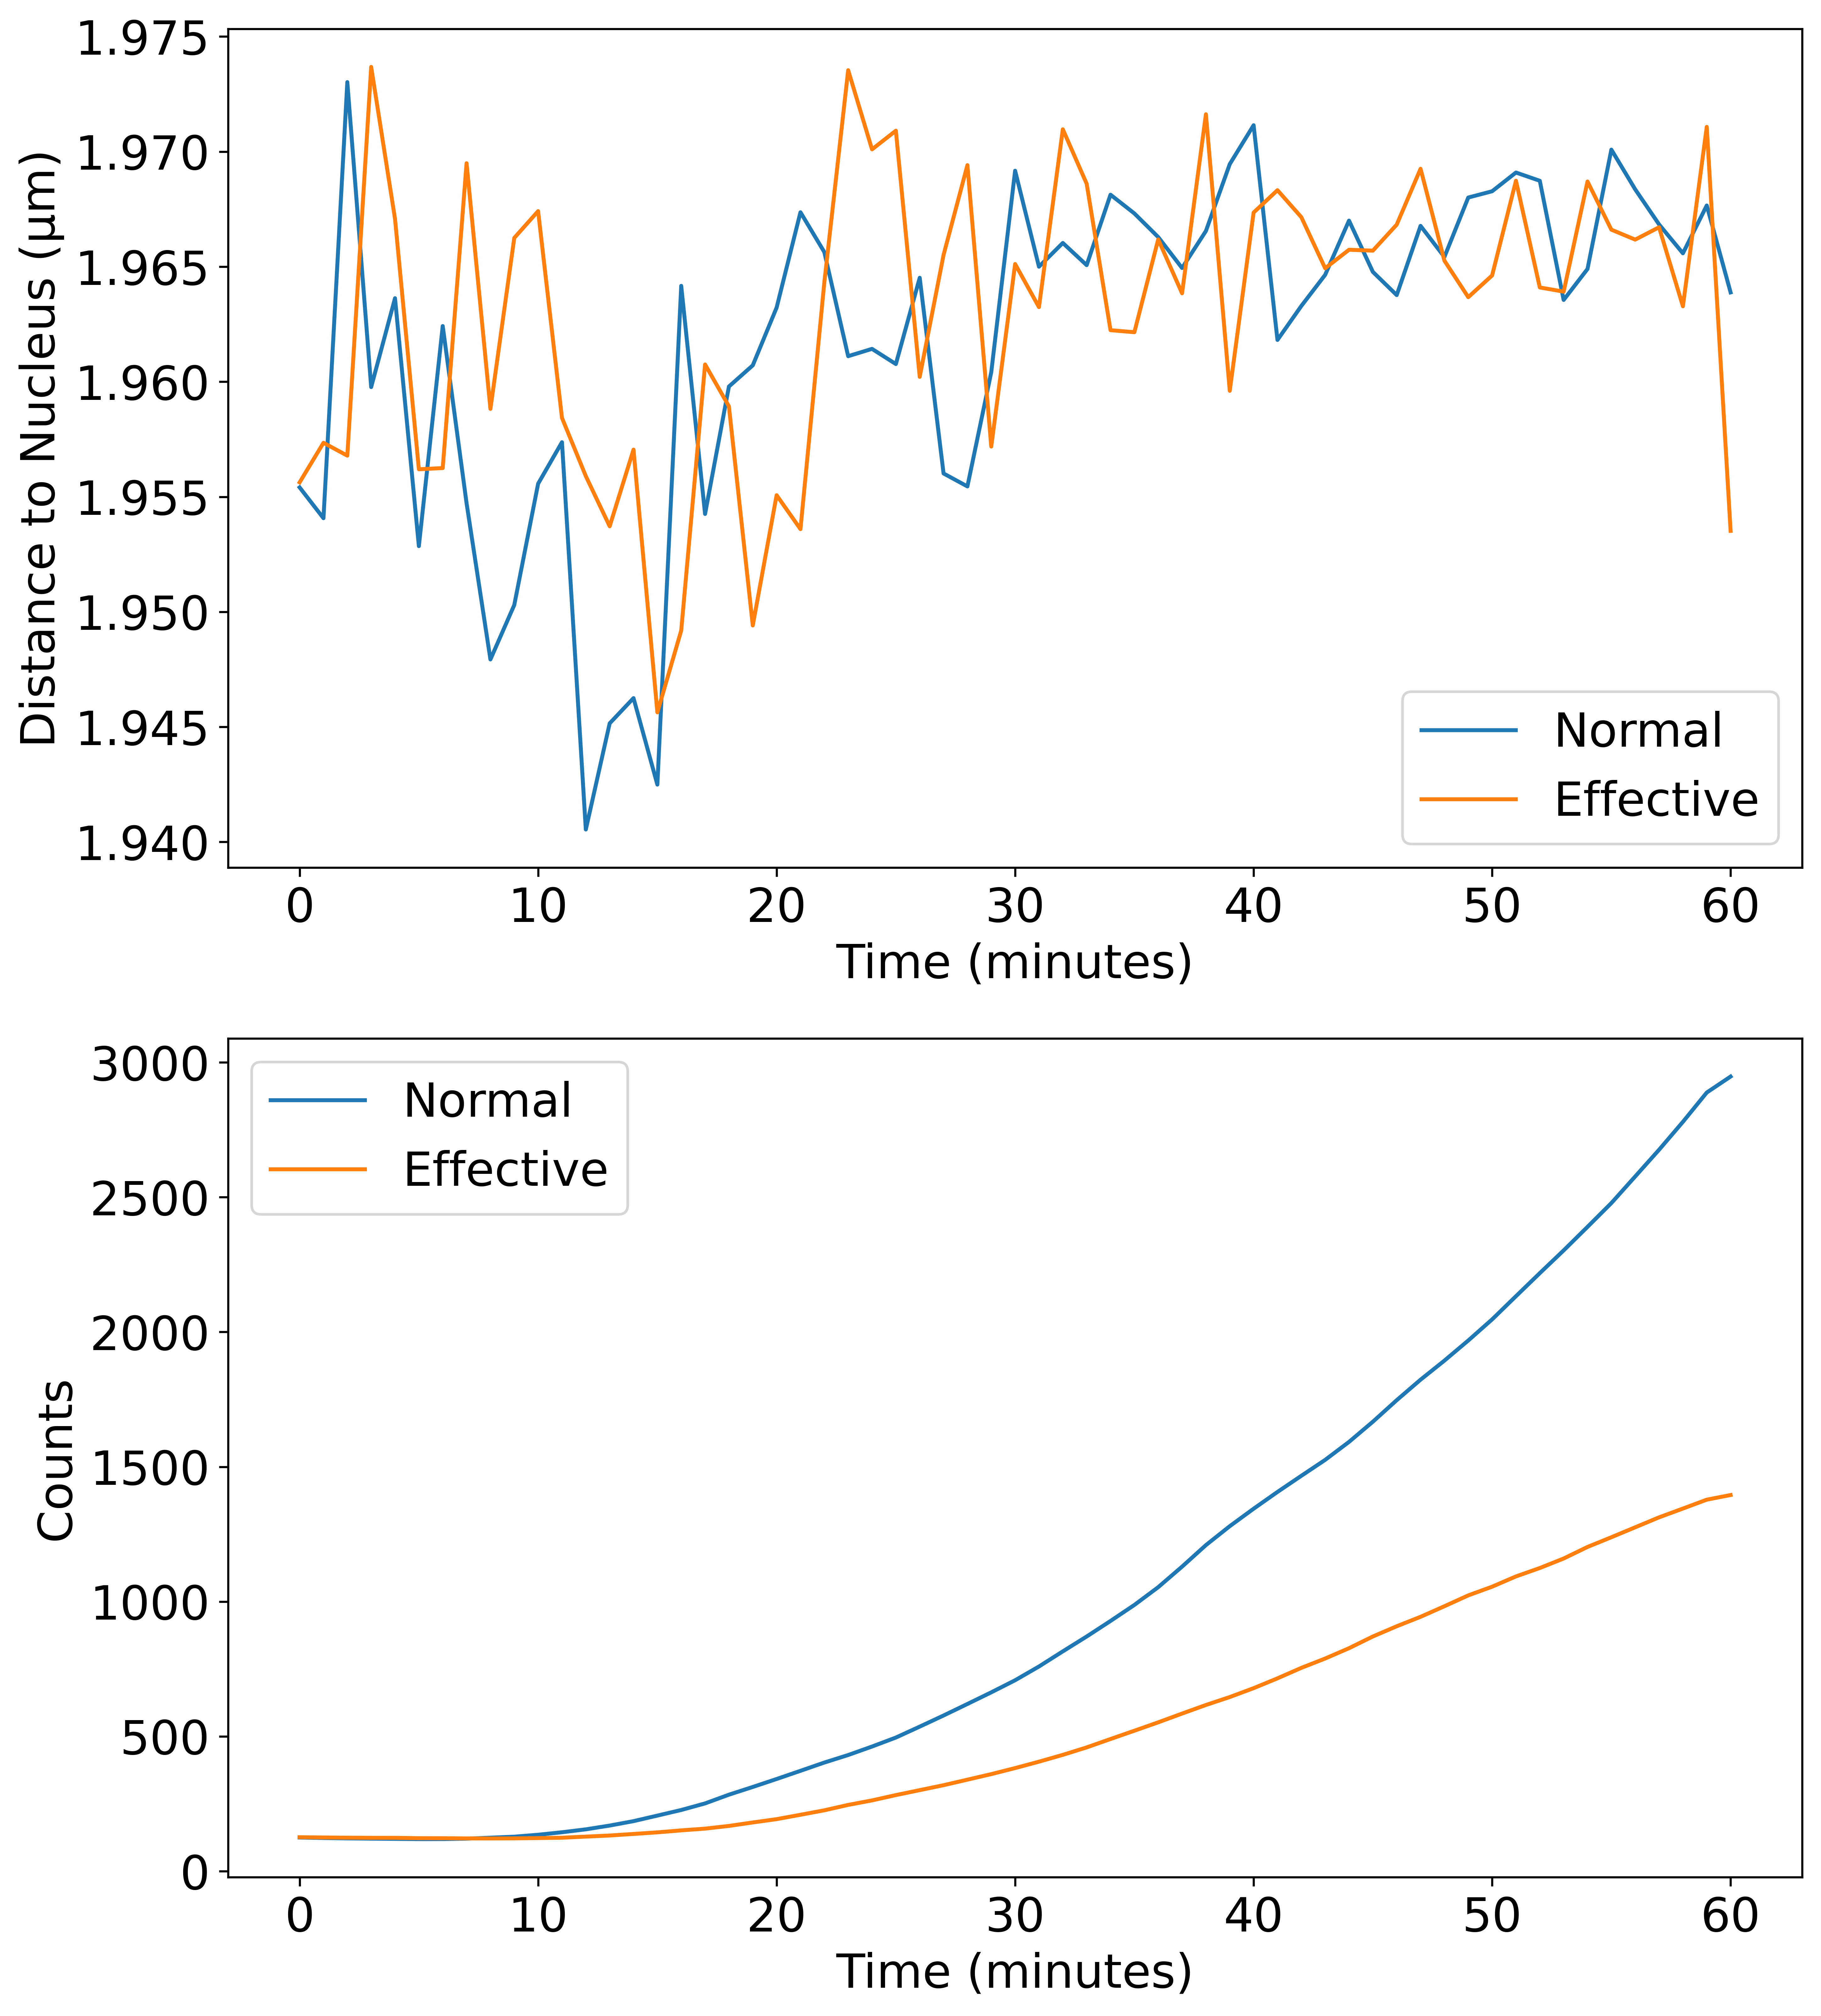

(({0: 69.69062433188864,
   1: 69.45623879415193,
   2: 68.95851422846519,
   3: 69.25137042671837,
   4: 70.71736082230736,
   5: 69.93084088278295,
   6: 69.45727783976493,
   7: 69.0186237786157,
   8: 68.5718596712099,
   9: 68.74736196911816,
   10: 67.93534540132794,
   11: 67.6063443199372,
   12: 66.57857572772309,
   13: 68.82225146493852,
   14: 69.9032139937304,
   15: 68.27148803543666,
   16: 67.95058972453027,
   17: 68.28183675906614,
   18: 68.4161517411602,
   19: 67.28777706211021,
   20: 67.61007579939073,
   21: 67.42339355821817,
   22: 67.67338166359332,
   23: 68.53730666266331,
   24: 68.37114398000797,
   25: 70.43493107967724,
   26: 68.5594388952144,
   27: 70.1569728740952,
   28: 68.9090569336111,
   29: 69.05478068208807,
   30: 67.78142609231854,
   31: 66.15968613280353,
   32: 65.10661418513291,
   33: 66.33786940214739,
   34: 66.6826945439358,
   35: 65.1289813467751,
   36: 65.44130588820927,
   37: 66.65679272756539,
   38: 65.57456233135194,
   39:

In [30]:
import os 
# Example usage
condition1_file_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250310_wtnoer_60min"
condition2_file_dir = "/data2/2024_Yeast_GS/my_current_code/rdme_ode_results/20250326_wtnoer_riboeff_1787"
condition1_files = [os.path.join(condition1_file_dir, f) for f in os.listdir(condition1_file_dir) if f.endswith('ribosome_coords.csv')]
condition2_files = [os.path.join(condition2_file_dir, f) for f in os.listdir(condition2_file_dir) if f.endswith('ribosome_coords.csv')]

compare_distance_and_counts(
    condition1_files, 
    condition2_files,
    set1_label="Normal",
    set2_label="Effective",
    output_dir=condition2_file_dir
)